In [1]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table 

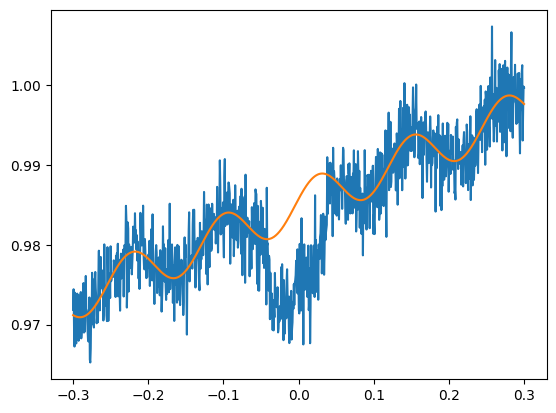

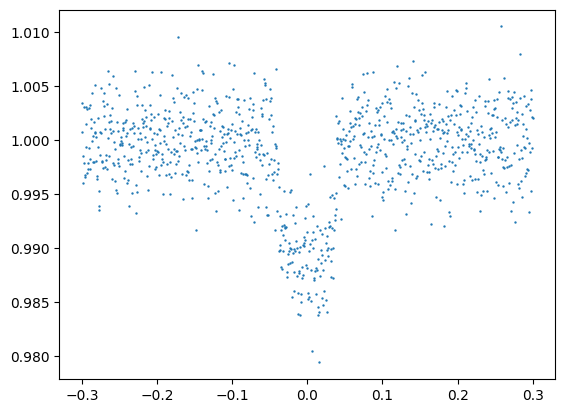

In [ ]:
''' 
    To Groupmates:
        My code isn't fully finished yet, but it works functionally
        here are the variables I created that you guys might need for your part of the code

        x_data -- an array of the raw x_values (Time [Days])
        y_data -- an array of the raw y_values (Flux)
        clean_y -- an array of the cleaned up y_data
        perr -- array of the standard deviation for each parameter from curve_fit

'''

#model that returns a linearlly growing sinusoidal model
def model_test(x,m,b,A,B,C):
    return m*x+b+A*np.sin(B*x + C)

#open the table to extract the data for the x and y values
light_data = Table.read("Planet_Lightcurve.fits")
x_data = light_data["time [days]"]
y_data = light_data["flux"]
    

#Since there seems to be an oscillitory artifact at around x = 0,
#I loop through the x_values and remove any points that fall within -.05 < x < .05
x_sample, y_sample = [],[]
for i in range(len(x_data)):
    if x_data[i] < -.05 or x_data[i] > .05:
        x_sample.append(x_data[i])
        y_sample.append(y_data[i])
    
#initial guesses for the curve_fit function
p0 = [.03,3,.1,-50,-20]
  
popt,pocv = curve_fit(model_test,x_sample,y_sample, sigma=.003, p0=p0)

#array of standard deviations for my best fit values,
perr = np.sqrt(np.diag(pocv))



#divide the artifacts out of the y_data by using the constants found from curve_fit
clean_y = y_data / model_test(x_data,*popt)
    
#create a plot the plots the model over the original data
plt.plot(x_data,y_data)
plt.plot(x_data, model_test(x_data,*popt))
plt.show()

#create a scatterplot of the cleaned up data 
plt.scatter(x_data,clean_y, s=.5)
plt.show()
